In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
import json
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Reload config ─────────────────────────────────────────
with open('../data/transformer_config.json') as f:
    cfg = json.load(f)

print("Loaded config:")
for k, v in cfg.items():
    print(f"  {k}: {v}")

# ── Rebuild model architecture ────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(1))

    def forward(self, x):
        return self.dropout(x + self.pe[:x.size(0)])


class MultiFeatureTransformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead,
                 num_encoder_layers, dim_feedforward,
                 dropout, lookback, horizon):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc    = PositionalEncoding(d_model,
                              max_len=lookback+10, dropout=dropout)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=False
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_encoder_layers
        )
        self.decoder = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, horizon)
        )

    def get_embedding(self, x):
        x = x.permute(1, 0, 2)
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.transformer_encoder(x)
        return x[-1]                      # (batch, d_model)

    def forward(self, x):
        return self.decoder(self.get_embedding(x))


# Load weights
transformer = MultiFeatureTransformer(**{
    k: cfg[k] for k in ['input_dim','d_model','nhead',
                         'num_encoder_layers','dim_feedforward',
                         'dropout','lookback','horizon']
}).to(device)

transformer.load_state_dict(
    torch.load('../data/best_transformer_multifeature.pt',
               map_location=device)
)
transformer.eval()
print("\n✅ Transformer loaded and ready")

# Load scalers
scaler_X = joblib.load('../data/scaler_X.pkl')
scaler_y = joblib.load('../data/scaler_y.pkl')
print("✅ Scalers loaded")

# Load master data
master = pd.read_csv("../data/master_congestion_final.csv")
print(f"✅ Master data loaded: {master.shape}")

Loaded config:
  input_dim: 4
  d_model: 64
  nhead: 4
  num_encoder_layers: 3
  dim_feedforward: 128
  dropout: 0.1
  lookback: 100
  horizon: 30
  feature_cols: ['avg_speed', 'vehicle_count', 'total_flow', 'flow_imbalance']
  target_col: avg_speed
  best_val_loss: 0.02710399208157215
  epochs_trained: 21

✅ Transformer loaded and ready


C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


✅ Scalers loaded
✅ Master data loaded: (271245, 17)


In [2]:
LOOKBACK     = cfg['lookback']
FEATURE_COLS = cfg['feature_cols']
D_MODEL      = cfg['d_model']

location_groups = {
    'A.Zhandong':       ['A.Zhandong Road1',
                         'A.Zhandong Road2'],
    'B.Dongying':       ['B.Dongying Road1',
                         'B.Dongying Road2'],
    'C.Ulanqab':        ['C.Ulanqab East Street1',
                         'C.Ulanqab East Street2',
                         'C.Ulanqab East Street3',
                         'C.Ulanqab East Street4'],
    "D.Xing'an":        ["D.Xing'an South Road1",
                         "D.Xing'an South Road2"],
    "E.People's Hall":  ["E.People's Hall1",
                         "E.People's Hall2"],
    'F.South':          ['F.South intersection1',
                         'F.South intersection2'],
    'G.Xinhua':         ['G.Xinhua Square1',
                         'G.Xinhua Square2'],
    'H.Zhongshan':      ['H.Zhongshan  Road1',
                         'H.Zhongshan  Road2'],
}

locations   = sorted(location_groups.keys())
max_segments = max(len(v) for v in location_groups.values())

print(f"Locations:    {len(locations)}")
print(f"Max segments: {max_segments}")
print(f"D_model:      {D_MODEL}\n")


def extract_embedding(model, df_segment, feature_cols,
                      scaler_X, lookback, device):
    """
    Extract a single embedding vector from one segment.
    Uses the LAST lookback window — most recent traffic state.
    """
    features = df_segment[feature_cols].values.astype(np.float32)

    # Normalize using the training scaler
    features = scaler_X.transform(features)

    # Pad if segment shorter than lookback
    if len(features) < lookback:
        pad = np.zeros((lookback - len(features), len(feature_cols)),
                       dtype=np.float32)
        features = np.vstack([pad, features])

    # Take last lookback frames
    window = features[-lookback:]               # (lookback, n_features)
    x = torch.tensor(window).unsqueeze(0).to(device)  # (1, lookback, n_features)

    with torch.no_grad():
        emb = model.get_embedding(x)            # (1, d_model)

    return emb.squeeze(0).cpu().numpy()         # (d_model,)


# Extract embeddings for every segment
print("Extracting embeddings...\n")
segment_embeddings = {}

for loc in locations:
    segments = location_groups[loc]
    print(f"{loc}:")
    for seg in segments:
        subset = master[master['source'] == seg].sort_values('frame_num')
        if len(subset) == 0:
            print(f"  ⚠️  {seg}: no data found")
            continue
        emb = extract_embedding(
            transformer, subset, FEATURE_COLS,
            scaler_X, LOOKBACK, device
        )
        segment_embeddings[seg] = emb
        print(f"  ✅ {seg:<40} "
              f"embedding: {emb.shape}  "
              f"norm: {np.linalg.norm(emb):.3f}")
    print()

print(f"Total embeddings extracted: {len(segment_embeddings)}")

Locations:    8
Max segments: 4
D_model:      64

Extracting embeddings...

A.Zhandong:


C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  ✅ A.Zhandong Road1                         embedding: (64,)  norm: 7.337
  ✅ A.Zhandong Road2                         embedding: (64,)  norm: 7.415

B.Dongying:
  ✅ B.Dongying Road1                         embedding: (64,)  norm: 7.502
  ✅ B.Dongying Road2                         embedding: (64,)  norm: 7.400

C.Ulanqab:
  ✅ C.Ulanqab East Street1                   embedding: (64,)  norm: 7.510


C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Standar

  ✅ C.Ulanqab East Street2                   embedding: (64,)  norm: 7.688
  ✅ C.Ulanqab East Street3                   embedding: (64,)  norm: 7.537
  ✅ C.Ulanqab East Street4                   embedding: (64,)  norm: 7.470

D.Xing'an:
  ✅ D.Xing'an South Road1                    embedding: (64,)  norm: 7.530
  ✅ D.Xing'an South Road2                    embedding: (64,)  norm: 7.472

E.People's Hall:
  ✅ E.People's Hall1                         embedding: (64,)  norm: 7.371


C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Standar

  ✅ E.People's Hall2                         embedding: (64,)  norm: 7.333

F.South:
  ✅ F.South intersection1                    embedding: (64,)  norm: 7.338
  ✅ F.South intersection2                    embedding: (64,)  norm: 7.692

G.Xinhua:
  ✅ G.Xinhua Square1                         embedding: (64,)  norm: 7.460
  ✅ G.Xinhua Square2                         embedding: (64,)  norm: 7.489

H.Zhongshan:


C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  ✅ H.Zhongshan  Road1                       embedding: (64,)  norm: 7.682
  ✅ H.Zhongshan  Road2                       embedding: (64,)  norm: 7.457

Total embeddings extracted: 18


C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# Shape: (n_nodes=8, max_segments=4, d_model=64)
node_embeddings = np.zeros(
    (len(locations), max_segments, D_MODEL), dtype=np.float32
)
segment_mask = np.zeros(
    (len(locations), max_segments), dtype=bool
)

for i, loc in enumerate(locations):
    for t, seg in enumerate(location_groups[loc]):
        if seg in segment_embeddings:
            node_embeddings[i, t, :] = segment_embeddings[seg]
            segment_mask[i, t] = True

print("Node embedding tensor:")
print(f"  Shape: {node_embeddings.shape}")
print(f"  = ({len(locations)} nodes, "
      f"{max_segments} max_segments, "
      f"{D_MODEL} d_model)\n")

print("Segment availability per node:")
for i, loc in enumerate(locations):
    real = segment_mask[i].sum()
    pad  = max_segments - real
    bar  = '█' * real + '░' * pad
    print(f"  {loc:<20} [{bar}] "
          f"{real} real  {pad} padded")

# Save
np.save('../data/node_embeddings.npy',  node_embeddings)
np.save('../data/segment_mask.npy',     segment_mask)
np.save('../data/locations_list.npy',   np.array(locations))

print("\n✅ Saved:")
print("  node_embeddings.npy  — (8, 4, 64)")
print("  segment_mask.npy     — (8, 4) bool")
print("  locations_list.npy   — location names")

Node embedding tensor:
  Shape: (8, 4, 64)
  = (8 nodes, 4 max_segments, 64 d_model)

Segment availability per node:
  A.Zhandong           [██░░] 2 real  2 padded
  B.Dongying           [██░░] 2 real  2 padded
  C.Ulanqab            [████] 4 real  0 padded
  D.Xing'an            [██░░] 2 real  2 padded
  E.People's Hall      [██░░] 2 real  2 padded
  F.South              [██░░] 2 real  2 padded
  G.Xinhua             [██░░] 2 real  2 padded
  H.Zhongshan          [██░░] 2 real  2 padded

✅ Saved:
  node_embeddings.npy  — (8, 4, 64)
  segment_mask.npy     — (8, 4) bool
  locations_list.npy   — location names


PCA explained variance: 70.1% + 19.8% = 89.9%


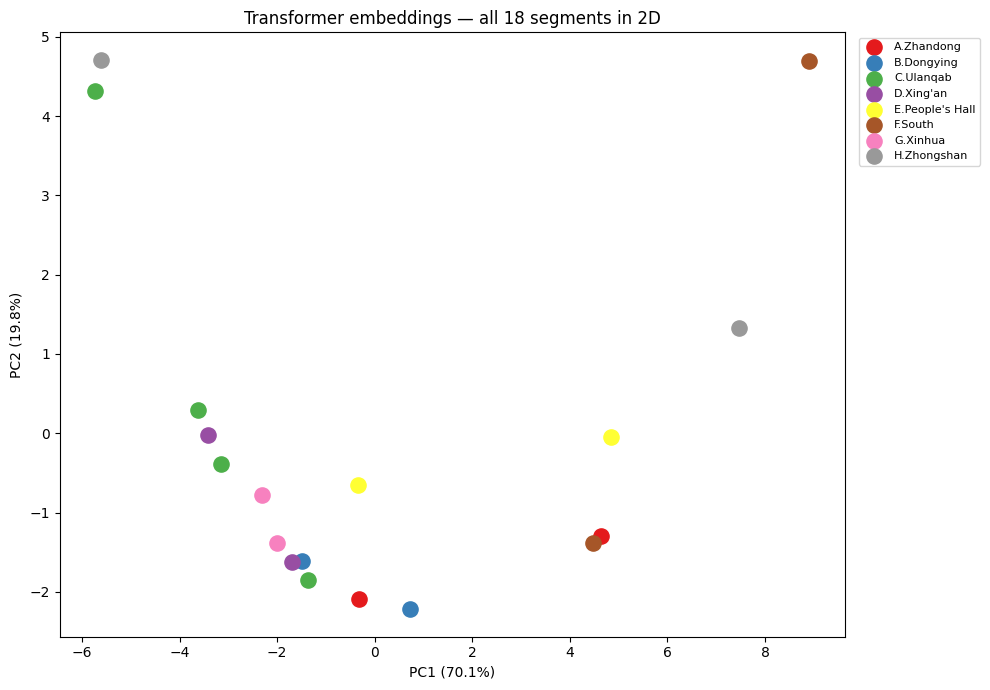

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA to visualize 64-dim embeddings in 2D
# Each segment is one point — nearby = similar traffic behavior
all_embs   = []
all_labels = []
all_times  = []

for i, loc in enumerate(locations):
    for t, seg in enumerate(location_groups[loc]):
        if segment_mask[i, t]:
            all_embs.append(node_embeddings[i, t, :])
            all_labels.append(loc)
            all_times.append(t)

all_embs = np.array(all_embs)
pca = PCA(n_components=2)
embs_2d = pca.fit_transform(all_embs)

print(f"PCA explained variance: "
      f"{pca.explained_variance_ratio_[0]:.1%} + "
      f"{pca.explained_variance_ratio_[1]:.1%} = "
      f"{sum(pca.explained_variance_ratio_):.1%}")

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Set1(np.linspace(0, 1, len(locations)))

for i, loc in enumerate(locations):
    mask = [l == loc for l in all_labels]
    xs = embs_2d[mask, 0]
    ys = embs_2d[mask, 1]
    ts = [all_times[j] for j, m in enumerate(mask) if m]
    ax.scatter(xs, ys, color=colors[i], s=120,
               label=loc, zorder=5)
    for x, y, t in zip(xs, ys, ts):
        ax.annotate(f"T{t+1}", (x, y),
                    fontsize=8, ha='center', va='center',
                    color='white', fontweight='bold')

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Transformer embeddings — all 18 segments in 2D')
plt.tight_layout()
plt.savefig('../data/embedding_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ── Load saved artifacts ──────────────────────────────────
node_embeddings = np.load('../data/node_embeddings.npy')
segment_mask    = np.load('../data/segment_mask.npy')
adj_matrix      = np.load('../data/adjacency_matrix.npy')
locations       = list(np.load('../data/locations_list.npy'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N_NODES      = node_embeddings.shape[0]   # 8
MAX_SEGMENTS = node_embeddings.shape[1]   # 4
D_MODEL      = node_embeddings.shape[2]   # 64

print(f"Nodes:        {N_NODES}")
print(f"Max segments: {MAX_SEGMENTS}")
print(f"D_model:      {D_MODEL}")
print(f"Adj matrix:   {adj_matrix.shape}")

emb_tensor = torch.tensor(node_embeddings, dtype=torch.float32).to(device)
adj_tensor = torch.tensor(adj_matrix,      dtype=torch.float32).to(device)


# ── Dynamic GNN ───────────────────────────────────────────
class GraphConvolution(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W    = nn.Linear(in_dim, out_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x, adj):
        deg      = adj.sum(dim=1, keepdim=True).clamp(min=1)
        adj_norm = adj / deg
        return F.relu(torch.matmul(adj_norm, self.W(x)) + self.bias)


class DynamicTrafficGNN(nn.Module):
    def __init__(self, d_model=64, hidden=128,
                 out_dim=30, n_nodes=8, max_segments=4):
        super().__init__()
        self.gcn1          = GraphConvolution(d_model, hidden)
        self.gcn2          = GraphConvolution(hidden, hidden)
        self.temporal_attn = nn.Linear(hidden, 1)
        self.predictor     = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, out_dim)
        )

    def forward(self, node_embs, adj, mask):
        """
        node_embs: (n_nodes, max_segments, d_model)
        adj:       (n_nodes, n_nodes)
        mask:      (n_nodes, max_segments) bool
        returns:   predictions (n_nodes, out_dim)
                   attn_weights (n_nodes, max_segments)
        """
        n_nodes, max_seg, _ = node_embs.shape
        seg_outputs = []

        for t in range(max_seg):
            x_t = node_embs[:, t, :]      # (n_nodes, d_model)
            h   = self.gcn1(x_t, adj)     # (n_nodes, hidden)
            h   = self.gcn2(h, adj)        # (n_nodes, hidden)
            seg_outputs.append(h)

        H = torch.stack(seg_outputs, dim=1)  # (n_nodes, max_seg, hidden)

        # Temporal attention with mask
        attn = self.temporal_attn(H).squeeze(-1)  # (n_nodes, max_seg)
        mask_t = torch.tensor(mask, dtype=torch.float32, device=node_embs.device)
        attn   = attn.masked_fill(mask_t == 0, -1e9)
        attn_w = F.softmax(attn, dim=1)           # (n_nodes, max_seg)

        context = (attn_w.unsqueeze(-1) * H).sum(dim=1)  # (n_nodes, hidden)
        return self.predictor(context), attn_w


gnn = DynamicTrafficGNN(
    d_model=D_MODEL, hidden=128,
    out_dim=30, n_nodes=N_NODES,
    max_segments=MAX_SEGMENTS
).to(device)

print(f"GNN parameters: {sum(p.numel() for p in gnn.parameters()):,}")


# ── Build targets per node ────────────────────────────────
master = pd.read_csv("../data/master_congestion_final.csv")

location_groups = {
    'A.Zhandong':       ['A.Zhandong Road1',       'A.Zhandong Road2'],
    'B.Dongying':       ['B.Dongying Road1',        'B.Dongying Road2'],
    'C.Ulanqab':        ['C.Ulanqab East Street1',  'C.Ulanqab East Street2',
                         'C.Ulanqab East Street3',  'C.Ulanqab East Street4'],
    "D.Xing'an":        ["D.Xing'an South Road1",   "D.Xing'an South Road2"],
    "E.People's Hall":  ["E.People's Hall1",         "E.People's Hall2"],
    'F.South':          ['F.South intersection1',   'F.South intersection2'],
    'G.Xinhua':         ['G.Xinhua Square1',         'G.Xinhua Square2'],
    'H.Zhongshan':      ['H.Zhongshan  Road1',       'H.Zhongshan  Road2'],
}

scaler_y = joblib.load('../data/scaler_y.pkl')

targets = np.zeros((N_NODES, 30), dtype=np.float32)
for i, loc in enumerate(locations):
    last_seg = location_groups[loc][-1]
    subset   = master[master['source'] == last_seg].sort_values('frame_num')
    speeds   = subset['avg_speed'].values[-30:].astype(np.float32)
    if len(speeds) < 30:
        speeds = np.pad(speeds, (30 - len(speeds), 0))
    # Scale to match transformer output space
    targets[i] = scaler_y.transform(speeds.reshape(-1,1)).flatten()

target_tensor = torch.tensor(targets, dtype=torch.float32).to(device)
print(f"Targets shape: {target_tensor.shape}")


# ── Training ──────────────────────────────────────────────
optimizer = torch.optim.Adam(gnn.parameters(), lr=1e-3)
criterion = nn.MSELoss()
EPOCHS    = 300

print(f"\nTraining Dynamic GNN for {EPOCHS} epochs...\n")

best_loss = float('inf')
for epoch in range(1, EPOCHS + 1):
    gnn.train()
    optimizer.zero_grad()
    preds, _ = gnn(emb_tensor, adj_tensor, segment_mask)
    loss     = criterion(preds, target_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        rmse = torch.sqrt(loss).item()
        print(f"  Epoch {epoch:03d} | MSE={loss.item():.5f} | RMSE={rmse:.5f}")

    if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save(gnn.state_dict(), '../data/best_gnn.pt')

print(f"\nBest MSE: {best_loss:.5f}")
print(f"Best RMSE: {np.sqrt(best_loss):.5f}")
print("Saved: best_gnn.pt")


# ── Inspect attention weights ─────────────────────────────
gnn.load_state_dict(torch.load('../data/best_gnn.pt', map_location=device))
gnn.eval()
with torch.no_grad():
    preds, attn_w = gnn(emb_tensor, adj_tensor, segment_mask)

attn_w = attn_w.cpu().numpy()
preds  = preds.cpu().numpy()
preds_real = scaler_y.inverse_transform(preds)

print("\nTemporal attention weights:")
print("(which recording session the GNN found most informative)\n")
for i, loc in enumerate(locations):
    segs    = location_groups[loc]
    weights = attn_w[i, :len(segs)]
    pred_mean = preds_real[i].mean()
    print(f"{loc} — predicted avg speed: {pred_mean:.2f} km/h")
    for t, (seg, w) in enumerate(zip(segs, weights)):
        bar = '█' * int(w * 40)
        print(f"  T{t+1} {seg:<40} {w:.3f}  {bar}")
    print()

np.save('../data/gnn_predictions.npy', preds_real)
np.save('../data/gnn_attention.npy',   attn_w)
print("Saved: gnn_predictions.npy, gnn_attention.npy")

Nodes:        8
Max segments: 4
D_model:      64
Adj matrix:   (8, 8)
GNN parameters: 45,343


C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Jaya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Standar

Targets shape: torch.Size([8, 30])

Training Dynamic GNN for 300 epochs...

  Epoch 050 | MSE=29.45289 | RMSE=5.42705
  Epoch 100 | MSE=26.05050 | RMSE=5.10397
  Epoch 150 | MSE=22.47375 | RMSE=4.74065
  Epoch 200 | MSE=18.98857 | RMSE=4.35759
  Epoch 250 | MSE=14.26228 | RMSE=3.77654
  Epoch 300 | MSE=1.01583 | RMSE=1.00788

Best MSE: 0.73493
Best RMSE: 0.85728
Saved: best_gnn.pt

Temporal attention weights:
(which recording session the GNN found most informative)

A.Zhandong — predicted avg speed: 8.20 km/h
  T1 A.Zhandong Road1                         0.432  █████████████████
  T2 A.Zhandong Road2                         0.568  ██████████████████████

B.Dongying — predicted avg speed: 8.12 km/h
  T1 B.Dongying Road1                         0.666  ██████████████████████████
  T2 B.Dongying Road2                         0.334  █████████████

C.Ulanqab — predicted avg speed: 5.67 km/h
  T1 C.Ulanqab East Street1                   0.291  ███████████
  T2 C.Ulanqab East Street2          

In [6]:
# Compare GNN predictions vs actual last 30 frames
print("GNN prediction vs actual last 30 frames:\n")
for i, loc in enumerate(locations):
    last_seg = location_groups[loc][-1]
    subset   = master[master['source'] == last_seg].sort_values('frame_num')
    actual   = subset['avg_speed'].values[-30:].mean()
    predicted = preds_real[i].mean()
    diff     = predicted - actual
    flag     = "⚠️" if abs(diff) > 3 else "✅"
    print(f"{flag} {loc:<22} "
          f"actual={actual:.2f}  "
          f"predicted={predicted:.2f}  "
          f"diff={diff:+.2f} km/h")

GNN prediction vs actual last 30 frames:

✅ A.Zhandong             actual=6.69  predicted=8.20  diff=+1.51 km/h
✅ B.Dongying             actual=7.48  predicted=8.12  diff=+0.64 km/h
✅ C.Ulanqab              actual=6.09  predicted=5.67  diff=-0.42 km/h
✅ D.Xing'an              actual=5.88  predicted=4.83  diff=-1.05 km/h
✅ E.People's Hall        actual=10.21  predicted=10.74  diff=+0.53 km/h
✅ F.South                actual=16.98  predicted=15.62  diff=-1.36 km/h
✅ G.Xinhua               actual=5.20  predicted=6.31  diff=+1.11 km/h
✅ H.Zhongshan            actual=13.42  predicted=14.35  diff=+0.93 km/h
